## Build My Own Linear Regression

We will be using a Housing Prices Dataset [https://www.kaggle.com/datasets/yasserh/housing-prices-dataset] to test our own linear regression implementation

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

### Obtain Data

In [67]:
path = kagglehub.dataset_download("yasserh/housing-prices-dataset")

print("Path to dataset files:", path)

Path to dataset files: /Users/edwinchleung/.cache/kagglehub/datasets/yasserh/housing-prices-dataset/versions/1


In [68]:
df = pd.read_csv(path + "/Housing.csv")

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [69]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [70]:
df['prefarea'].value_counts()

prefarea
no     417
yes    128
Name: count, dtype: int64

In [71]:
df = df.replace({'yes': 1, 'no': 0})

In [72]:
df['prefarea'].value_counts()

prefarea
0    417
1    128
Name: count, dtype: int64

In [73]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


In [74]:
features = ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea']

df[features].shape

(545, 11)

#### Our Linear Regression Class

In [ ]:
class LinearRegression:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights: np.ndarray = None
        self.bias: np.ndarray = None
        
        self.num_samples: int = None
        self.num_features: int = None
        self.samples_shape: tuple = None
        self.output_shape: tuple = None
        
    def fit(self, X: np.ndarray, y: np.ndarray, early_stopping_threshold: float = 1e-6) -> None:
        self.samples_shape = X.shape
        self.output_shape = y.shape
        self.num_samples, self.num_features = X.shape
        
        if self.num_samples == 0 or self.num_features == 0:
                raise ValueError("Input data X must have at least one sample and one feature.")
        
        if self.num_samples != y.shape[0]:
            raise ValueError("Number of samples in X and y must be the same.")
        
        self.weights = np.zeros(self.num_features)
        self.bias = 0
        
        last_mse = float('inf')
        
        for i in range(self.n_iterations):
            y_predicted = self.predict(X)
            error = y - y_predicted
            
            assert error.shape == y.shape, f"Error shape {error.shape} does not match y shape {y.shape}"
            
            mse = self.mean_squared_error(y, y_predicted)
            if abs(mse - last_mse) < early_stopping_threshold:
                print(f"Early stopping at iteration {i+1} due to small MSE: {mse:.6f}")
                break       
            
            dw = (-2 / self.num_samples) * np.dot(X.T, error)
            db = (-2 / self.num_samples) * error.sum()
            
            self.weights = self.weights - self.learning_rate * dw
            self.bias = self.bias - self.learning_rate * db
            
            if i % 10 == 0:
                print(f"Iteration {i+1}/{self.n_iterations}, MSE: {mse:.4f}")
                
            last_mse = mse
        
        return
        
    def predict(self, X: np.ndarray) -> np.ndarray:
        if self.weights is None or self.bias is None:
            raise ValueError("Model has not been fitted yet. Please call fit() before predict().")
        
        if self.samples_shape is not None and X.shape[1] != self.samples_shape[1]:
            raise ValueError(f"Input data X must have the same number of features as the training data. Expected {self.samples_shape[1]}, got {X.shape[1]}.")
        
        return self.bias + np.dot(X, self.weights)
    
    def mean_squared_error(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        if y_true.shape != y_pred.shape:
            raise ValueError("Shapes of y_true and y_pred must be the same.")
        
        return ((y_pred - y_true) ** 2).sum() / len(y_true)
    
    def r2_score(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        if y_true.shape != y_pred.shape:
            raise ValueError("Shapes of y_true and y_pred must be the same.")
        
        ss_res = ((y_true - y_pred) ** 2).sum()
        ss_tot = ((y_true - y_true.mean()) ** 2).sum()
        
        return 1 - (ss_res / ss_tot)
    
    def f_statistic(self, y_true: np.ndarray, y_pred: np.ndarray) -> float:
        if y_true.shape != y_pred.shape:
            raise ValueError("Shapes of y_true and y_pred must be the same.")
        
        ss_reg = ((y_pred - y_true.mean()) ** 2).sum()
        ss_res = ((y_true - y_pred) ** 2).sum()
        
        df_reg = self.num_features
        df_res = self.num_samples - self.num_features - 1
        
        ms_reg = ss_reg / df_reg
        ms_res = ss_res / df_res
        
        return ms_reg / ms_res
    
    def t_statistic(self, X: np.ndarray, y: np.ndarray) -> np.ndarray:
        if self.weights is None or self.bias is None:
            raise ValueError("Model has not been fitted yet. Please call fit() before t_statistic().")
        
        y_pred = self.predict(X)
        residuals = y - y_pred
        
        mse = self.mean_squared_error(y, y_pred)
        se = np.sqrt(mse / self.num_samples)
        
        t_stats = self.weights / se
        
        return t_stats
    

In [105]:
def min_max_scaling(X: np.ndarray) -> np.ndarray:
    if X.size == 0:
        raise ValueError("Input data X must not be empty.")
    
    min_vals = X.min(axis=0)
    max_vals = X.max(axis=0)
    
    if np.any(max_vals - min_vals == 0):
        raise ValueError("At least one feature has the same value for all samples, cannot perform min-max scaling.")
    
    scaled_X = (X - min_vals) / (max_vals - min_vals)
    
    return scaled_X

def transform_back_to_original_scale(scaled: np.ndarray, original_min: np.ndarray, original_max: np.ndarray) -> np.ndarray:
    if scaled.size == 0:
        raise ValueError("Input data scaled must not be empty.")
    
    if original_min.shape != original_max.shape:
        raise ValueError("Shapes of original_min and original_max must be the same.")
    
    if np.any(original_max - original_min == 0):
        raise ValueError("At least one feature has the same value for all samples in the original data, cannot perform inverse transformation.")
    
    original = scaled * (original_max - original_min) + original_min
    
    return original

In [106]:
linear_regression_model = LinearRegression(learning_rate=0.01, n_iterations=5000)

X = df[features].values
y = df['price'].values

X_scaled = min_max_scaling(X)
y_scaled = min_max_scaling(y.reshape(-1, 1)).flatten()
linear_regression_model.fit(X_scaled, y_scaled)

Iteration 1/5000, MSE: 0.0944
Iteration 11/5000, MSE: 0.0441
Iteration 21/5000, MSE: 0.0260
Iteration 31/5000, MSE: 0.0194
Iteration 41/5000, MSE: 0.0169
Iteration 51/5000, MSE: 0.0158
Iteration 61/5000, MSE: 0.0153
Iteration 71/5000, MSE: 0.0150
Iteration 81/5000, MSE: 0.0147
Iteration 91/5000, MSE: 0.0145
Iteration 101/5000, MSE: 0.0143
Iteration 111/5000, MSE: 0.0142
Iteration 121/5000, MSE: 0.0140
Iteration 131/5000, MSE: 0.0138
Iteration 141/5000, MSE: 0.0137
Iteration 151/5000, MSE: 0.0135
Iteration 161/5000, MSE: 0.0134
Iteration 171/5000, MSE: 0.0133
Iteration 181/5000, MSE: 0.0131
Iteration 191/5000, MSE: 0.0130
Iteration 201/5000, MSE: 0.0129
Iteration 211/5000, MSE: 0.0128
Iteration 221/5000, MSE: 0.0127
Iteration 231/5000, MSE: 0.0126
Iteration 241/5000, MSE: 0.0125
Iteration 251/5000, MSE: 0.0124
Iteration 261/5000, MSE: 0.0123
Iteration 271/5000, MSE: 0.0122
Iteration 281/5000, MSE: 0.0121
Iteration 291/5000, MSE: 0.0121
Iteration 301/5000, MSE: 0.0120
Iteration 311/5000,

In [107]:
linear_regression_model.weights, linear_regression_model.bias

(array([0.13358479869817738, 0.07137300729378819, 0.1470379097124761,
        0.12152114163605528, 0.04924074809931834, 0.03855649662343216,
        0.03045685027983536, 0.05788933869676842, 0.08940413213606907,
        0.10509063248586266, 0.06655426672222722], dtype=object),
 0.024909069016510892)

In [108]:
y_pred = linear_regression_model.predict(X_scaled)
y_pred = transform_back_to_original_scale(y_pred, y.min(), y.max())

print("R2 Score:", linear_regression_model.r2_score(y, y_pred))
print("F-statistic:", linear_regression_model.f_statistic(y, y_pred))

combined = pd.DataFrame({'features': features, 'weights': linear_regression_model.weights, 't-stats': linear_regression_model.t_statistic(X_scaled, y_scaled)})
print(combined)

R2 Score: 0.635397623931943
F-statistic: 70.72385629621722
           features   weights    t-stats
0              area  0.133585  31.921452
1          bedrooms  0.071373  17.055309
2         bathrooms  0.147038   35.13621
3           stories  0.121521  29.038718
4          mainroad  0.049241   11.76658
5         guestroom  0.038556   9.213469
6          basement  0.030457   7.277975
7   hotwaterheating  0.057889  13.833249
8   airconditioning  0.089404   21.36403
9           parking  0.105091   25.11248
10         prefarea  0.066554  15.903822


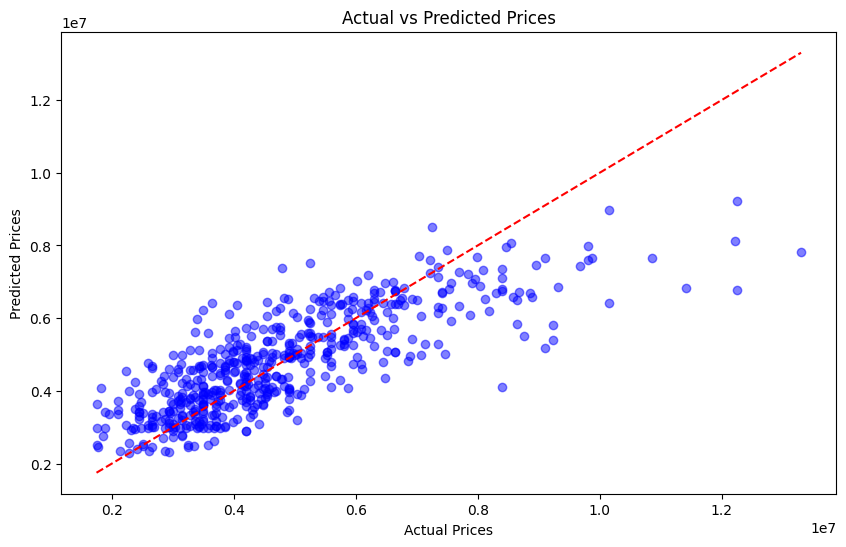

In [109]:
plt.figure(figsize=(10, 6))
plt.scatter(y, y_pred, color='blue', alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices')
plt.show()

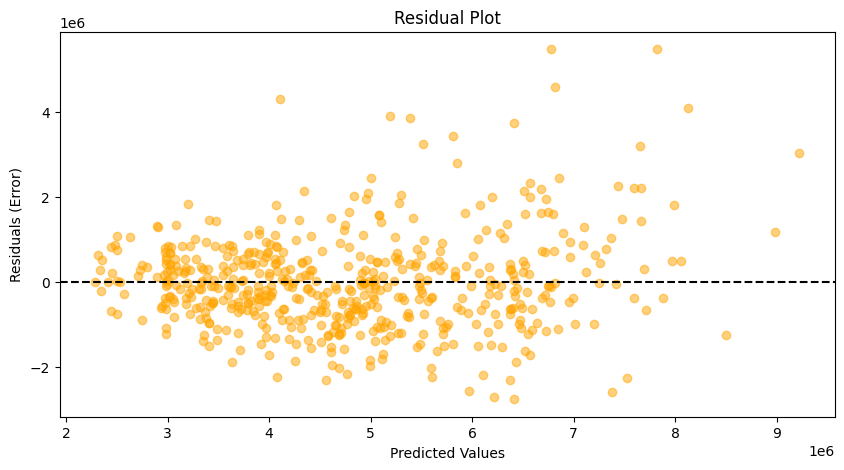

In [110]:
residuals = y - y_pred
plt.figure(figsize=(10, 5))
plt.scatter(y_pred, residuals, alpha=0.5, color='orange')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Error)')
plt.show()